In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
df = pd.read_csv('heart_disease2_modified.csv')
df.head()

,Unnamed: 0,Gender,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,Heart_ stroke
0,0,Male,39,no,0.0,no,no,no,no,195.0,106.0,70.0,26.97,80.0,77.0,No
1,1,Female,46,no,0.0,no,no,no,no,250.0,121.0,81.0,28.73,95.0,76.0,No
2,2,Male,48,yes,20.0,no,no,no,no,245.0,127.5,80.0,25.34,75.0,70.0,No
3,3,Female,61,yes,30.0,no,no,yes,no,225.0,150.0,95.0,28.58,65.0,103.0,yes
4,4,Female,46,yes,23.0,no,no,no,no,285.0,130.0,84.0,23.10,85.0,85.0,No


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       4238 non-null   int64  
 1   Gender           4238 non-null   object 
 2   age              4238 non-null   int64  
 3   currentSmoker    4238 non-null   object 
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4238 non-null   object 
 6   prevalentStroke  4238 non-null   object 
 7   prevalentHyp     4238 non-null   object 
 8   diabetes         4238 non-null   object 
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  Heart_ stroke    4238 non-null   object 
dtypes: float64(7), int64(2), object(7)
memory usage: 529.9+ KB


In [81]:
df.isnull().sum()

Unnamed: 0           0
Gender               0
age                  0
currentSmoker        0
cigsPerDay          29
BPMeds               0
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
Heart_ stroke        0
dtype: int64

In [82]:
df.dropna(inplace=True)

In [83]:
df.isnull().sum()

Unnamed: 0         0
Gender             0
age                0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
Heart_ stroke      0
dtype: int64

In [84]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [85]:
df.rename(columns={'Heart_ stroke':'Heart_stroke'},inplace=True)

In [86]:
df.head()

,Gender,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,Heart_stroke
0,Male,39,no,0.0,no,no,no,no,195.0,106.0,70.0,26.97,80.0,77.0,No
1,Female,46,no,0.0,no,no,no,no,250.0,121.0,81.0,28.73,95.0,76.0,No
2,Male,48,yes,20.0,no,no,no,no,245.0,127.5,80.0,25.34,75.0,70.0,No
3,Female,61,yes,30.0,no,no,yes,no,225.0,150.0,95.0,28.58,65.0,103.0,yes
4,Female,46,yes,23.0,no,no,no,no,285.0,130.0,84.0,23.10,85.0,85.0,No


In [87]:
df['Gender'] = df['Gender'].apply(lambda x:1 if x == 'Male' else 0)
df['currentSmoker'] = df['currentSmoker'].apply(lambda x:1 if x == 'yes' else 0)
df['BPMeds'] = df['BPMeds'].apply(lambda x:1 if x == 'yes' else 0)
df['prevalentStroke'] = df['prevalentStroke'].apply(lambda x:1 if x == 'yes' else 0)
df['prevalentHyp'] = df['prevalentHyp'].apply(lambda x:1 if x == 'yes' else 0)
df['diabetes'] = df['diabetes'].apply(lambda x:1 if x == 'yes' else 0)
df['Heart_stroke'] = df['Heart_stroke'].apply(lambda x:1 if x == 'yes' else 0)
df.head(10)

,Gender,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,Heart_stroke
0,1,39,0,0.0,0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,0,0.0,0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,0,63,0,0.0,0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1
7,0,45,1,20.0,0,0,0,0,313.0,100.0,71.0,21.68,79.0,78.0,0
8,1,52,0,0.0,0,0,1,0,260.0,141.5,89.0,26.36,76.0,79.0,0
9,1,43,1,30.0,0,0,1,0,225.0,162.0,107.0,23.61,93.0,88.0,0


In [88]:
X = df.drop(columns=['Heart_stroke'])
y = df['Heart_stroke']

In [89]:
from sklearn.model_selection import train_test_split

In [90]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2)

In [91]:
from sklearn.neighbors import KNeighborsClassifier

In [92]:
KNN = KNeighborsClassifier()
KNN.fit(X_train,y_train)
acc_knn = KNN.score(X_test,y_test)

In [93]:
from sklearn.svm import SVC

In [94]:
svc = SVC()
svc.fit(X_train,y_train)
acc_svc = svc.score(X_test,y_test)

In [95]:
from sklearn.naive_bayes import GaussianNB

In [96]:
nb = GaussianNB()
nb.fit(X_train,y_train)
acc_nb = nb.score(X_test,y_test)

In [97]:
from sklearn.neural_network import MLPClassifier

In [98]:
neural_network = MLPClassifier()
neural_network.fit(X_train,y_train)
acc_nn = neural_network.score(X_test,y_test)

In [99]:
from sklearn.tree import DecisionTreeClassifier

In [100]:
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)
acc_dt = dt.score(X_test,y_test)

In [101]:
from sklearn.ensemble import RandomForestClassifier

In [102]:
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
acc_rf = rf.score(X_test,y_test)
acc_rf

0.8513157894736842

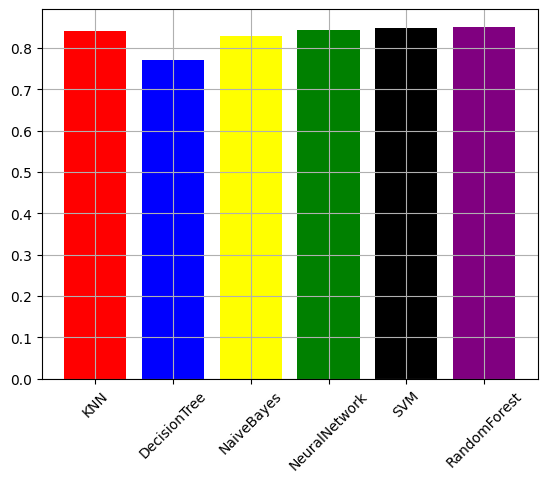

In [103]:
models = [acc_knn,acc_dt,acc_nb,acc_nn,acc_svc,acc_rf]
models_name = ['KNN','DecisionTree','NaiveBayes','NeuralNetwork','SVM','RandomForest']
colors = ['red','blue','yellow','green','black','purple']
plt.bar(models_name,models,color=colors)
plt.grid()
plt.xticks(rotation=45)
plt.savefig('Models.png')
plt.show()

In [104]:
max_model = max(models)
max_model

0.8513157894736842

In [105]:
import pickle as pk

In [106]:
pk.dump(max_model,open('model.pkl','wb'))